DEEP AGENTS

Build agents that can plan, use subagents, and leverage file systems for complex tasks.

deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. Built on LangGraph and inspired by applications like Claude Code, Deep Research, and Manus, deep agents come with planning capabilities, file systems for context management, and the ability to spawn subagents.

WHEN TO USE DEEP AGENTS

Use deep agents when you need agents that can:

- Handle complex, multi-step tasks that require planning and decomposition
- Manage large amounts of context through file system tools
- Delegate work to specialized subagents for context isolation
- Persist memory across conversations and threads

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [2]:
from langchain.chat_models import init_chat_model

model = init_chat_model("groq:openai/gpt-oss-20b")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000226DB0FE120>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000226DB0FEE40>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [14]:
from tavily import TavilyClient
from typing import Literal

tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query : str, max_results : int=5, include_raw_content : bool=False, topic : Literal["general","news"]="general"):
    """"Run a web search"""
    return tavily_client.search(query=query, max_results=max_results, include_raw_content=include_raw_content, topic=topic)

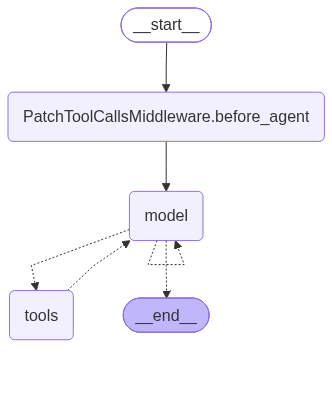

In [15]:
from deepagents import create_deep_agent

deep_agent = create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="You are a professional researcher"
)
deep_agent

In [16]:
result = deep_agent.invoke({"messages" : [{"role" : "user", "content" : "Tell me everything about deep agents."}]})
result

{'messages': [HumanMessage(content='Tell me everything about deep agents.', additional_kwargs={}, response_metadata={}, id='a96e1933-daac-4d0e-901e-e1c0d8f630b5'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to provide comprehensive information about deep agents. Likely refers to deep learning agents, reinforcement learning, or deep agents in AI. Could be "DeepAgent" as a concept, or "Deep Agents" in literature. The user wants everything. We need to gather info. Use web search? Allowed. We can use web_search. Also might search local files? There may be no local files. Let\'s search web.', 'tool_calls': [{'id': 'fc_448c6c96-ccf1-41ae-ba5c-460bd8c595d9', 'function': {'arguments': '{"max_results":10,"query":"deep agents AI","topic":"general"}', 'name': 'web_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 122, 'prompt_tokens': 2028, 'total_tokens': 2150, 'completion_time': 0.128226272, 'completion_tokens_details': {'reas

In [17]:
result["messages"][-1].content

'## Deep\u202fAgents – The Next‑Generation AI Workhorse  \n\n| Aspect | What it means | Why it matters |\n|--------|----------------|----------------|\n| **Goal** | Autonomous, long‑running agents that can *plan*, *remember*, *delegate*, and *act* over hours/days. | Enables complex, multi‑step workflows (research, coding, compliance) that would otherwise require a human. |\n| **Core Idea** | Build on the same “LLM\u202f+\u202ftool‑calling” loop as any agent, but add *state*, *planning*, *sub‑agent orchestration*, and *persistent memory*. | Turns a single‑turn agent into a “system” that can carry context across sessions and handle very large problem spaces. |\n| **Key Pillars** | 1. **Planning**  <br> 2. **Sub‑Agents**  <br> 3. **Persistent Memory**  <br> 4. **Context Management**  <br> 5. **Tool Execution & Skills** | Each pillar addresses a pain point of shallow agents: brittle task decomposition, short‑term context, statelessness, memory loss, and limited tool‑integration. |\n\n---\n

In [18]:
result["files"]

{}

WHAT HAPPENED?

Your deep agent automatically:
- Planned its approach: Used the built-in write_todos tool to break down the research task
- Conducted research: Called the web_search tool to gather information
- Managed context: Used file system tools (write_file, read_file) to offload large search results
- Spawned subagents (if needed): Delegated complex subtasks to specialized subagents
- Synthesized a report: Compiled findings into a coherent response